## SETUP


In [1]:
import pandas as pd, matplotlib.pyplot as plt
def load_data(p): return pd.read_csv(p)
def cc_stats(df):
    vals=pd.to_numeric(df['cc_delta'],errors='coerce').dropna()
    return vals.mean(),vals.median(),vals.std(),len(vals)
def raw_stats(df,col):
    vals=pd.to_numeric(df[col],errors='coerce').dropna()
    return pd.Series({'mean':f'{vals.mean():.2f}','median':f'{vals.median():.2f}',
                      'std':f'{vals.std():.2f}','min':f'{vals.min():.2f}',
                      'max':f'{vals.max():.2f}','n':len(vals)})


### Load result to data frame


In [2]:
single=load_data('single/result.csv'); multi=load_data('multi/result.csv')


# RAW CC -- All Entries


#### Overall CC Δ


Single (n=279):  ΔCC = -0.03 +/- 1.29  (median: +0.00)
Multi (n=279):  ΔCC = -0.30 +/- 1.82  (median: +0.00)


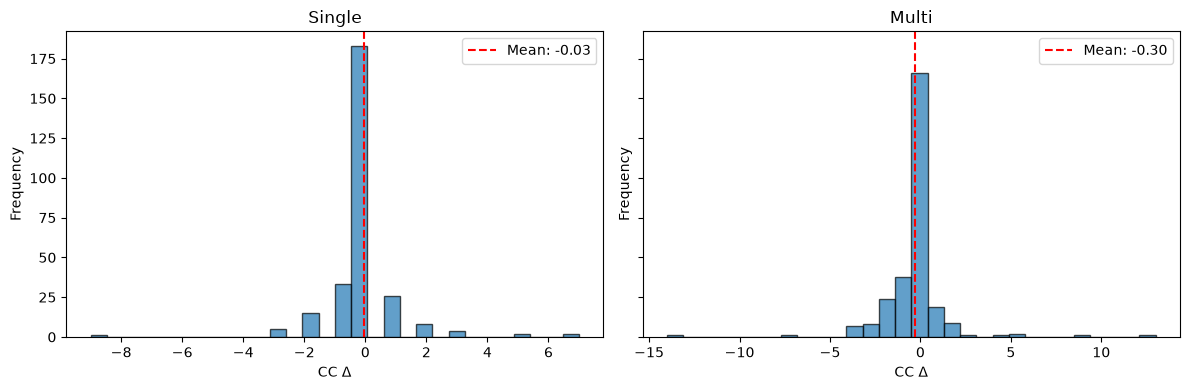

Breakdown by exit_status:
  Multi ABORT_STRATEGY (n=81):  ΔCC = -0.38 +/- 3.03
  Multi SUCCESS (n=198):  ΔCC = -0.26 +/- 0.96
  Single NO_CHANGE (n=7):  ΔCC = +0.00 +/- 0.00
  Single SUCCESS (n=272):  ΔCC = -0.03 +/- 1.30


In [3]:
for label,df in [('Single',single),('Multi',multi)]:
    m,med,s,n=cc_stats(df)
    print(f'{label} (n={n}):  ΔCC = {m:+.2f} +/- {s:.2f}  (median: {med:+.2f})')
fig,axes=plt.subplots(1,2,figsize=(12,4),sharey=True)
for ax,(label,df) in zip(axes,[('Single',single),('Multi',multi)]):
    vals=pd.to_numeric(df['cc_delta'],errors='coerce').dropna()
    ax.hist(vals,bins=30,edgecolor='black',alpha=0.7)
    ax.axvline(vals.mean(),color='red',linestyle='--',label=f'Mean: {vals.mean():+.2f}')
    ax.set_title(label); ax.set_xlabel('CC Δ'); ax.set_ylabel('Frequency'); ax.legend()
plt.tight_layout(); plt.show()
print('Breakdown by exit_status:')
for es,grp in pd.concat([single.assign(source='Single'),multi.assign(source='Multi')]).groupby(['source','exit_status']):
    m,med,s,n=cc_stats(grp)
    print(f'  {es[0]} {es[1]} (n={n}):  ΔCC = {m:+.2f} +/- {s:.2f}')


#### Raw CC Values (Original vs Refactored)


=== Single ===
       original_cc refactored_cc cc_delta
mean          4.92          4.89    -0.03
median        4.00          4.00     0.00
std           2.67          2.78     1.29
min           1.00          1.00    -9.00
max          17.00         17.00     7.00
n              279           279      279

=== Multi ===
       original_cc refactored_cc cc_delta
mean          4.92          4.62    -0.30
median        4.00          4.00     0.00
std           2.67          2.66     1.82
min           1.00          1.00   -14.00
max          17.00         16.00    13.00
n              279           279      279



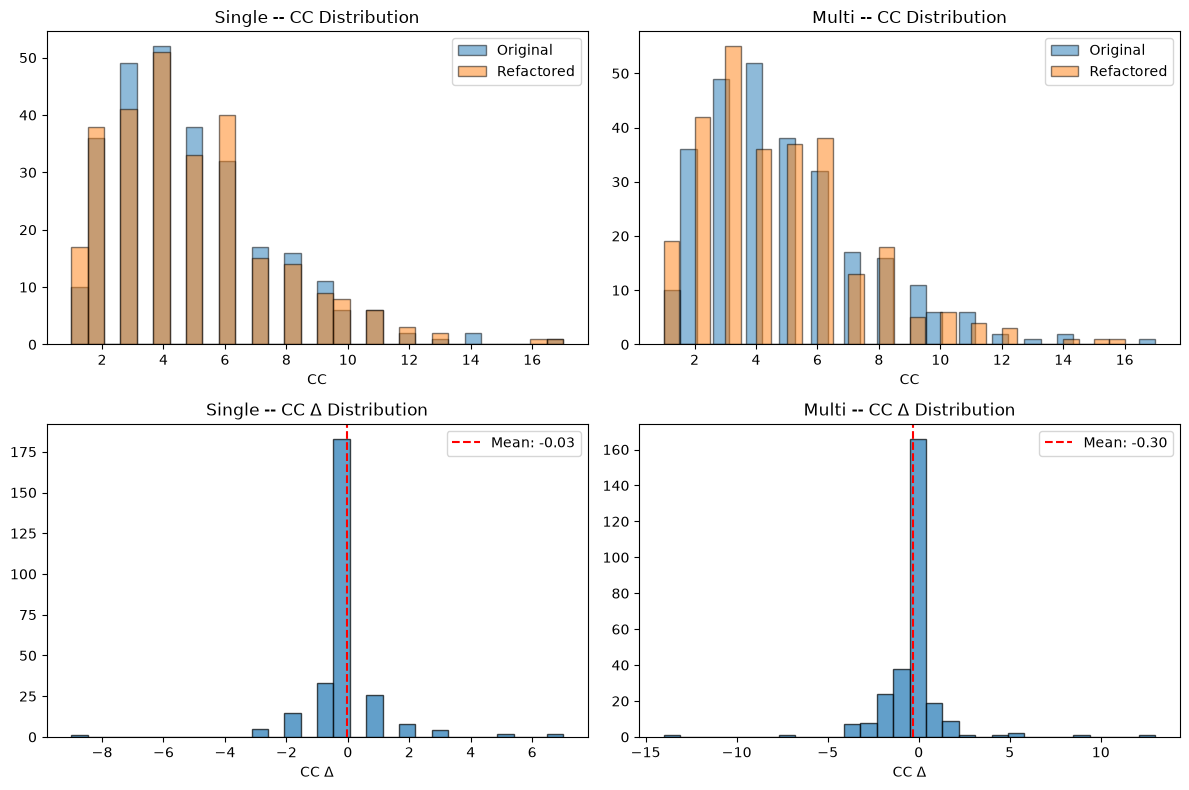

In [4]:
cols=['original_cc','refactored_cc','cc_delta']
for label,df in [('Single',single),('Multi',multi)]:
    print(f'=== {label} ===')
    print(pd.DataFrame({c:raw_stats(df,c) for c in cols})); print()
fig,axes=plt.subplots(2,2,figsize=(12,8))
for i,(label,df) in enumerate([('Single',single),('Multi',multi)]):
    orig=pd.to_numeric(df['original_cc'],errors='coerce').dropna()
    refa=pd.to_numeric(df['refactored_cc'],errors='coerce').dropna()
    axes[0][i].hist(orig,bins=30,alpha=0.5,label='Original',edgecolor='black')
    axes[0][i].hist(refa,bins=30,alpha=0.5,label='Refactored',edgecolor='black')
    axes[0][i].set_title(f'{label} -- CC Δistribution'); axes[0][i].set_xlabel('CC'); axes[0][i].legend()
    delta=pd.to_numeric(df['cc_delta'],errors='coerce').dropna()
    axes[1][i].hist(delta,bins=30,edgecolor='black',alpha=0.7)
    axes[1][i].axvline(delta.mean(),color='red',linestyle='--',label=f'Mean: {delta.mean():+.2f}')
    axes[1][i].set_title(f'{label} -- CC Δ Distribution'); axes[1][i].set_xlabel('CC Δ'); axes[1][i].legend()
plt.tight_layout(); plt.show()


#### Per-Intent CC Δ


                            Single  Multi
intent                                   
CONSOLIDATE_CONDITIONAL       0.23  -0.63
DECOMPOSE_CONDITIONAL         0.29   0.43
EXTRACT_CONSTANT              0.10   0.10
EXTRACT_METHOD               -0.12  -0.24
EXTRACT_VARIABLE              0.00   0.33
FLATTEN_CONDITIONAL           0.40   0.40
INLINE_METHOD                 0.38   0.76
INLINE_VARIABLE               0.12  -0.44
REMOVE_CONTROL_FLAG          -1.00  -1.25
RENAME_SYMBOL                 0.00   0.00
REPLACE_LOOP_WITH_PIPELINE   -1.25  -1.56
SPLIT_LOOP                   -0.56  -2.32


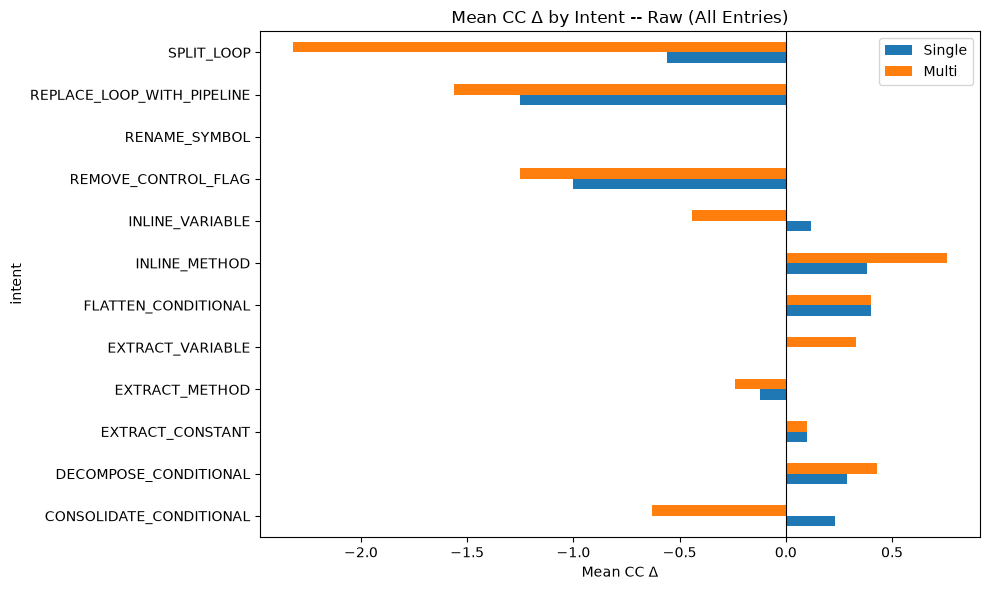

In [5]:
def intent_cc(df):
    return df.groupby('intent')['cc_delta'].apply(lambda x:pd.to_numeric(x,errors='coerce').mean()).round(2)
cc_intent=pd.DataFrame({'Single':intent_cc(single),'Multi':intent_cc(multi)})
print(cc_intent)
ax=cc_intent.plot.barh(figsize=(10,6))
ax.axvline(0,color='black',linewidth=0.8)
ax.set_title('Mean CC Δ by Intent -- Raw (All Entries)')
ax.set_xlabel('Mean CC Δ'); plt.tight_layout(); plt.show()


#### CC Δ by Difficulty


            Single  Multi
difficulty               
Easy          0.01  -0.22
Hard         -0.29  -0.56
Medium        0.04  -0.24


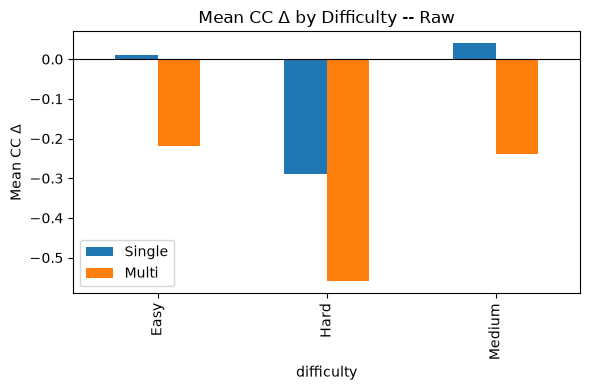

In [6]:
def diff_cc(df):
    return df.groupby('difficulty')['cc_delta'].apply(lambda x:pd.to_numeric(x,errors='coerce').mean()).round(2)
cc_diff=pd.DataFrame({'Single':diff_cc(single),'Multi':diff_cc(multi)})
print(cc_diff)
ax=cc_diff.plot.bar(figsize=(6,4))
ax.axhline(0,color='black',linewidth=0.8)
ax.set_title('Mean CC Δ by Difficulty -- Raw'); ax.set_ylabel('Mean CC Δ')
plt.tight_layout(); plt.show()


# CC -- SUCCESS Exit Only


#### Overall CC Δ (SUCCESS Only)


Single (n=272):  ΔCC = -0.03 +/- 1.30  (median: +0.00)
Multi (n=198):  ΔCC = -0.26 +/- 0.96  (median: +0.00)


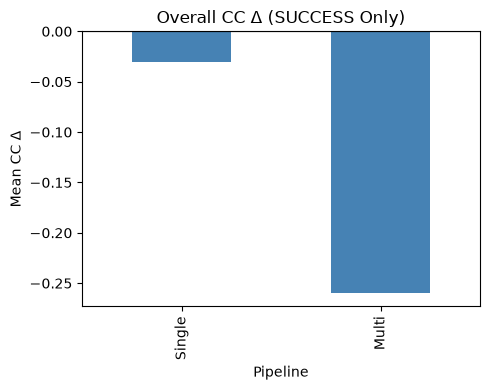

In [7]:
s_valid=single[single['exit_status']=='SUCCESS']
m_valid=multi[multi['exit_status']=='SUCCESS']
rows=[]
for label,df in [('Single',s_valid),('Multi',m_valid)]:
    m,med,s,n=cc_stats(df)
    print(f'{label} (n={n}):  ΔCC = {m:+.2f} +/- {s:.2f}  (median: {med:+.2f})')
    rows.append({'Pipeline':label,'ΔCC':round(m,2)})
pd.DataFrame(rows).set_index('Pipeline').plot.bar(figsize=(5,4),color=['steelblue','coral'],legend=False)
plt.axhline(0,color='black',linewidth=0.8); plt.ylabel('Mean CC Δ'); plt.title('Overall CC Δ (SUCCESS Only)')
plt.tight_layout(); plt.show()


#### Per-Intent CC Δ (SUCCESS Only)


                            Single  Multi
intent                                   
CONSOLIDATE_CONDITIONAL       0.26  -1.40
DECOMPOSE_CONDITIONAL         0.29   0.32
EXTRACT_CONSTANT              0.11   0.00
EXTRACT_METHOD               -0.12  -0.24
EXTRACT_VARIABLE              0.00   0.00
FLATTEN_CONDITIONAL           0.40  -0.80
INLINE_METHOD                 0.38   0.00
INLINE_VARIABLE               0.14  -0.44
REMOVE_CONTROL_FLAG          -1.00  -1.50
RENAME_SYMBOL                 0.00   0.00
REPLACE_LOOP_WITH_PIPELINE   -1.25  -1.56
SPLIT_LOOP                   -0.56  -0.67


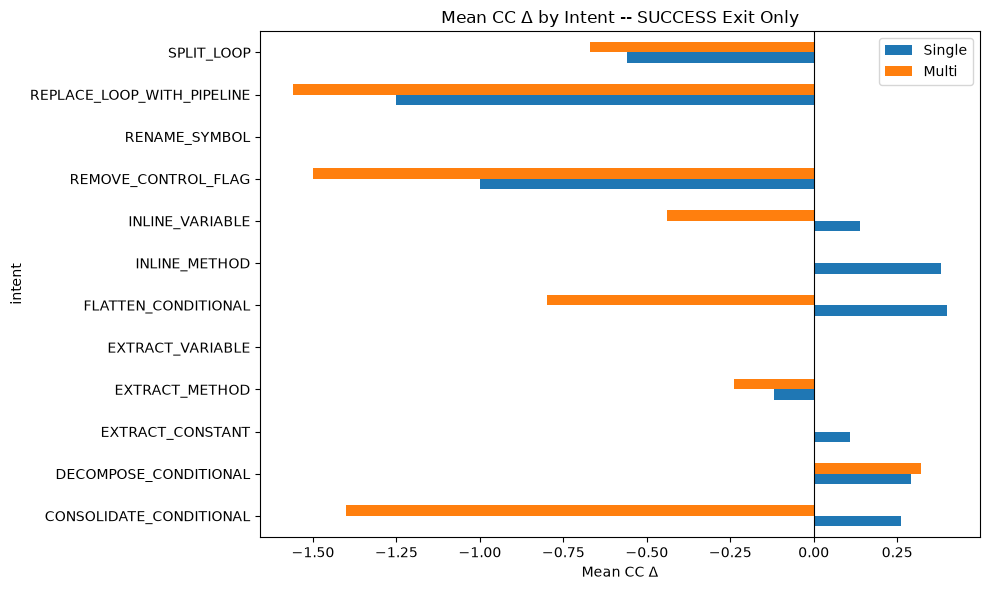

In [8]:
s_valid=single[single['exit_status']=='SUCCESS']
m_valid=multi[multi['exit_status']=='SUCCESS']
cc_succ=pd.DataFrame({'Single':intent_cc(s_valid),'Multi':intent_cc(m_valid)})
print(cc_succ)
ax=cc_succ.plot.barh(figsize=(10,6))
ax.axvline(0,color='black',linewidth=0.8)
ax.set_title('Mean CC Δ by Intent -- SUCCESS Exit Only')
ax.set_xlabel('Mean CC Δ'); plt.tight_layout(); plt.show()


#### CC Δ by Difficulty (SUCCESS Only)


            Single  Multi
difficulty               
Easy          0.01  -0.31
Hard         -0.31  -0.28
Medium        0.04  -0.23


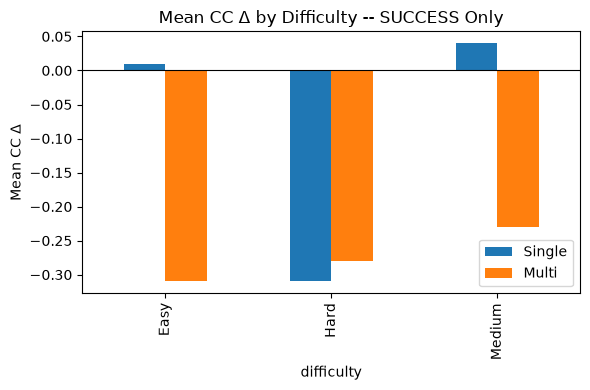

In [9]:
s_valid=single[single['exit_status']=='SUCCESS']
m_valid=multi[multi['exit_status']=='SUCCESS']
cc_diff_succ=pd.DataFrame({'Single':diff_cc(s_valid),'Multi':diff_cc(m_valid)})
print(cc_diff_succ)
ax=cc_diff_succ.plot.bar(figsize=(6,4))
ax.axhline(0,color='black',linewidth=0.8)
ax.set_title('Mean CC Δ by Difficulty -- SUCCESS Only'); ax.set_ylabel('Mean CC Δ')
plt.tight_layout(); plt.show()
